## This notebook plots certain assessment plots for a certain model

In [43]:
current_diffusion = "hjm_pca_reformatted with claude 15-4.csv" # "mvp1_simulated_paths.csv" "mvp1 14-4.csv"
current_diffusion = current_diffusion[0:199] # truncate to 200 rows for testing (bcs contains 500 and we want to compare to generated witch contains 200)
historical_data = "/Users/kaat/Desktop/Thesis Repository/Thesis-ALM/testing/historical data train.csv"


First check csv file of current diffusion has correct column names, if not replace with the following:


Scenario_ID,Month,Y_1M,Y_3M,Y_6M,Y_1Y,Y_2Y,Y_3Y,Y_5Y,Y_7Y,Y_10Y,Y_20Y,Y_30Y


## volatility

compare average volatility between early timesteps and late timesteps

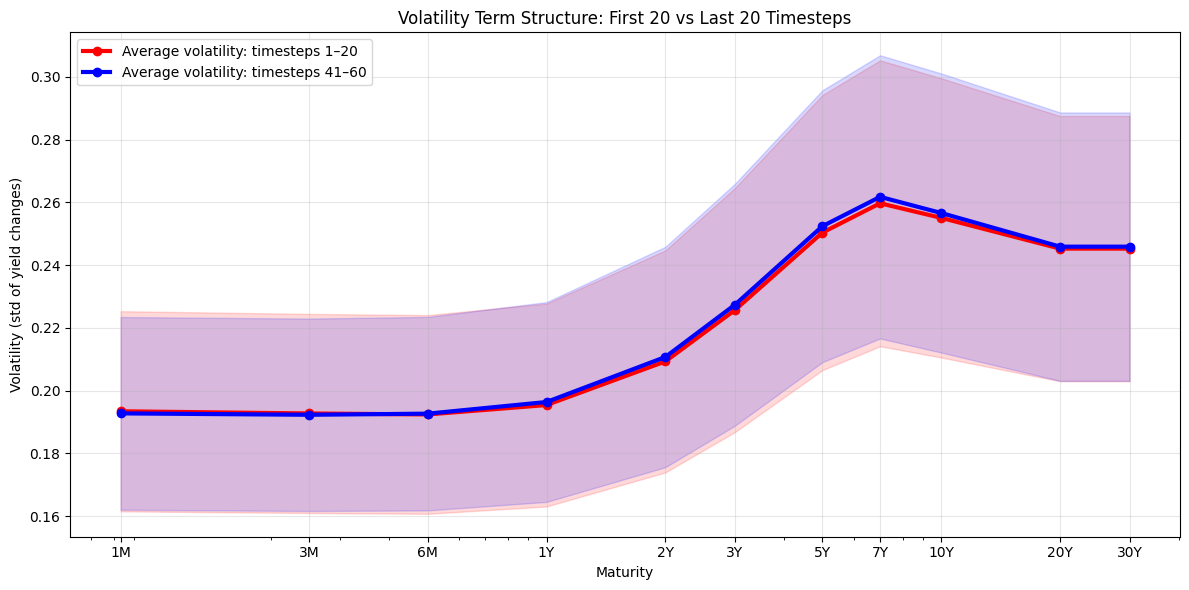

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# LOAD DATA
# ==============================
sim = pd.read_csv(current_diffusion)

sim_yield_cols = [c for c in sim.columns if c.startswith("Y_")]
maturities     = [c.replace("Y_", "") for c in sim_yield_cols]
maturity_years = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]

scenarios = sim["Scenario_ID"].unique()

# ==============================
# SETTINGS
# ==============================
EARLY_START = 0    # timestep 1
EARLY_END   = 20   # timestep 20 inbegrepen in iloc slicing via [0:20]

LATE_START  = 40   # timestep 41
LATE_END    = 60   # timestep 60 inbegrepen via [40:60]

# ==============================
# STORE VOLS
# ==============================
early_vols = []
late_vols  = []

for s in scenarios:
    scenario = sim[sim["Scenario_ID"] == s].sort_values("Month").reset_index(drop=True)
    yields = scenario[sim_yield_cols]

    # eerste 20 timesteps
    early_window = yields.iloc[EARLY_START:EARLY_END]
    early_vol = early_window.diff().dropna().std()
    early_vols.append(early_vol.values)

    # laatste 20 timesteps
    late_window = yields.iloc[LATE_START:LATE_END]
    late_vol = late_window.diff().dropna().std()
    late_vols.append(late_vol.values)

early_vols = np.array(early_vols)
late_vols  = np.array(late_vols)

# ==============================
# AVERAGES + STD
# ==============================
early_avg = np.mean(early_vols, axis=0)
early_std = np.std(early_vols, axis=0)

late_avg = np.mean(late_vols, axis=0)
late_std = np.std(late_vols, axis=0)

# ==============================
# PLOT
# ==============================
fig, ax = plt.subplots(figsize=(12, 6))

# eerste 20 timesteps = rood
ax.plot(
    maturity_years,
    early_avg,
    color="red",
    linewidth=3,
    marker="o",
    label="Average volatility: timesteps 1–20"
)

ax.fill_between(
    maturity_years,
    early_avg - early_std,
    early_avg + early_std,
    color="red",
    alpha=0.15
)

# laatste 20 timesteps = blauw
ax.plot(
    maturity_years,
    late_avg,
    color="blue",
    linewidth=3,
    marker="o",
    label="Average volatility: timesteps 41–60"
)

ax.fill_between(
    maturity_years,
    late_avg - late_std,
    late_avg + late_std,
    color="blue",
    alpha=0.15
)

# ==============================
# STYLING
# ==============================
ax.set_xscale("log")
ax.set_xticks(maturity_years)
ax.set_xticklabels(maturities)

ax.set_xlabel("Maturity")
ax.set_ylabel("Volatility (std of yield changes)")
ax.set_title("Volatility Term Structure: First 20 vs Last 20 Timesteps")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

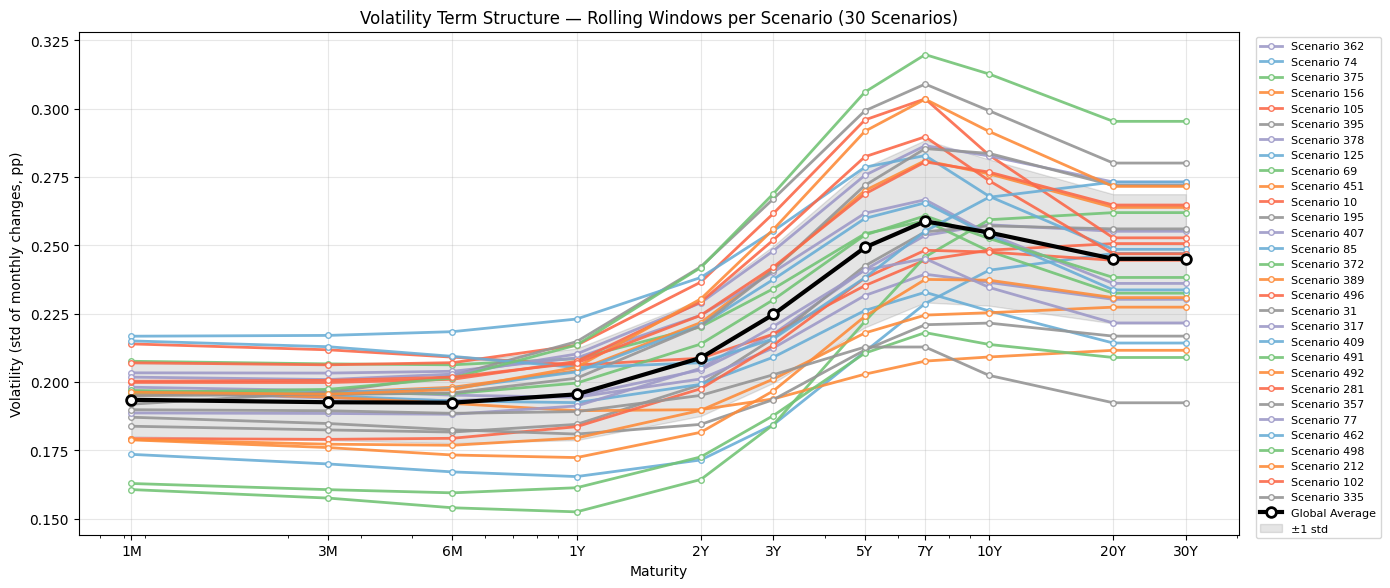

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# LOAD DATA
# ==============================
sim = pd.read_csv(current_diffusion)

sim_yield_cols = [c for c in sim.columns if c.startswith("Y_")]
maturities     = [c.replace("Y_", "") for c in sim_yield_cols]
maturity_years = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]

scenarios = sim["Scenario_ID"].unique()

# ==============================
# SETTINGS
# ==============================
WINDOW = 60
STEP   = 12
N_SCEN = 30

np.random.seed(42)
selected_scenarios = np.random.choice(scenarios, size=N_SCEN, replace=False)

# ==============================
# COLOR MAPS
# ==============================
colormaps = [
    plt.cm.Purples,
    plt.cm.Blues,
    plt.cm.Greens,
    plt.cm.Oranges,
    plt.cm.Reds,
    plt.cm.Greys
]

# ==============================
# PLOT
# ==============================
fig, ax = plt.subplots(figsize=(14, 6))

all_vols = []  # <-- collect ALL windows for average

for scen_idx, s in enumerate(selected_scenarios):

    scenario = sim[sim["Scenario_ID"] == s].sort_values("Month")
    yields = scenario[sim_yield_cols]

    windows = []
    for start in range(0, len(yields) - WINDOW + 1, STEP):
        window = yields.iloc[start : start + WINDOW]
        windows.append(window)

    cmap = colormaps[scen_idx % len(colormaps)]
    colors = cmap(np.linspace(0.5, 0.5, len(windows)))

    for i, (window, color) in enumerate(zip(windows, colors)):
        vol = window.diff().dropna().std()
        vol_values = [vol[col] for col in sim_yield_cols]

        # store for global average
        all_vols.append(vol_values)

        ax.plot(maturity_years, vol_values,
                color=color,
                linewidth=2,
                alpha=0.9,
                marker="o",
                markersize=4,
                markerfacecolor="white",
                markeredgewidth=1,
                label=f"Scenario {s}" if i == 0 else None)

# ==============================
# GLOBAL AVERAGE
# ==============================
all_vols = np.array(all_vols)

avg_vol = np.mean(all_vols, axis=0)
std_vol = np.std(all_vols, axis=0)

# --- average line ---
ax.plot(maturity_years, avg_vol,
        color="black",
        linewidth=3,
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=2,
        label="Global Average",
        zorder=10)

# --- optional std band ---
ax.fill_between(maturity_years,
                avg_vol - std_vol,
                avg_vol + std_vol,
                color="black",
                alpha=0.1,
                label="±1 std")

# ==============================
# STYLING
# ==============================
ax.set_xscale("log")
ax.set_xticks(maturity_years)
ax.set_xticklabels(maturities)

ax.set_xlabel("Maturity")
ax.set_ylabel("Volatility (std of monthly changes, pp)")
ax.set_title(f"Volatility Term Structure — Rolling Windows per Scenario ({N_SCEN} Scenarios)")

ax.grid(alpha=0.3)

ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
#plt.savefig("volatility_scenario_gradients_avg.png", dpi=150, bbox_inches="tight")
plt.show()

GEMIDDELDE MAANDELIJKSE VOL per maturity over alle scenarios
   1M: 19.69%
   3M: 19.64%
   6M: 19.65%
   1Y: 20.01%
   2Y: 21.44%
   3Y: 23.09%
   5Y: 25.57%
   7Y: 26.49%
  10Y: 25.96%
  20Y: 24.89%
  30Y: 24.89%


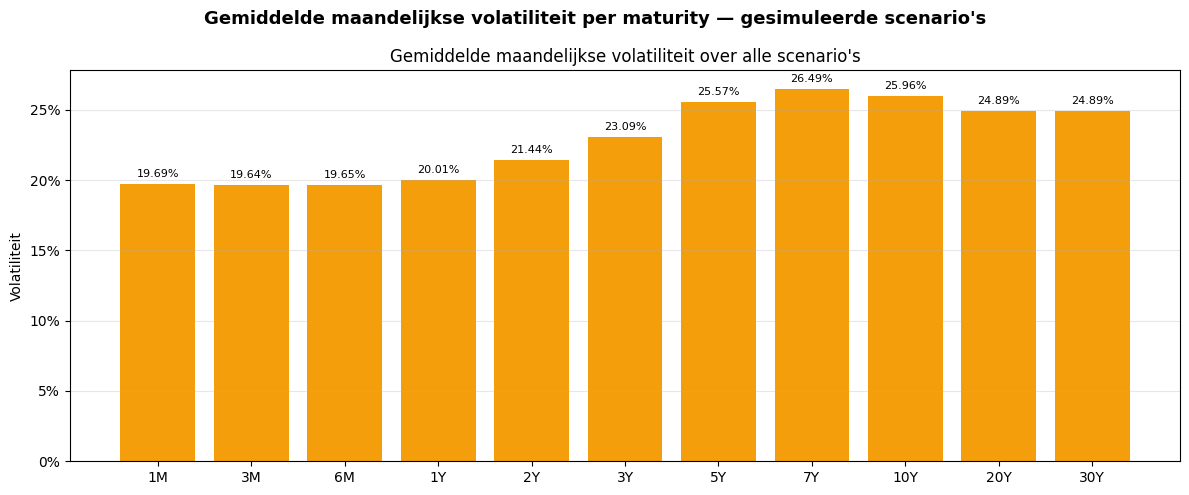

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv(current_diffusion)

yield_cols      = [c for c in df.columns if c.startswith("Y_")]
maturity_labels = {col: col.replace("Y_", "") for col in yield_cols}
maturities      = list(maturity_labels.values())
scenarios       = df["Scenario_ID"].unique()

def log_returns(series):
    s = series.replace(0, np.nan)
    return np.log(s / s.shift(1))

# For each scenario, for each maturity: compute monthly vol (std of log-returns × √12)
# Result: dict of lists, one vol per scenario
monthly_vols = {mat: [] for mat in maturities}

for s in scenarios:
    scenario = df[df["Scenario_ID"] == s].sort_values("Month")
    for col in yield_cols:
        mat = maturity_labels[col]
        ret = scenario[col].diff().dropna()
        monthly_vols[mat].append(ret.std())

# Average vol per maturity across all scenarios
monthly_avg = {mat: np.nanmean(monthly_vols[mat]) for mat in maturities}

# Print table
print("=" * 70)
print("GEMIDDELDE MAANDELIJKSE VOL per maturity over alle scenarios")
print("=" * 70)
for mat, val in monthly_avg.items():
    print(f"{mat:>5}: {val:.2%}")

# Plot
x = np.arange(len(maturities))

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Gemiddelde maandelijkse volatiliteit per maturity — gesimuleerde scenario's",
             fontsize=13, fontweight="bold")

bars = ax.bar(x, [monthly_avg[m] for m in maturities], color="#f59e0b")
ax.set_xticks(x)
ax.set_xticklabels(maturities)
ax.set_title("Gemiddelde maandelijkse volatiliteit over alle scenario's")
ax.set_ylabel("Volatiliteit")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, [monthly_avg[m] for m in maturities]):
    ax.annotate(f"{val:.2%}", xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
#plt.savefig("volatility_simulated_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

## ACF

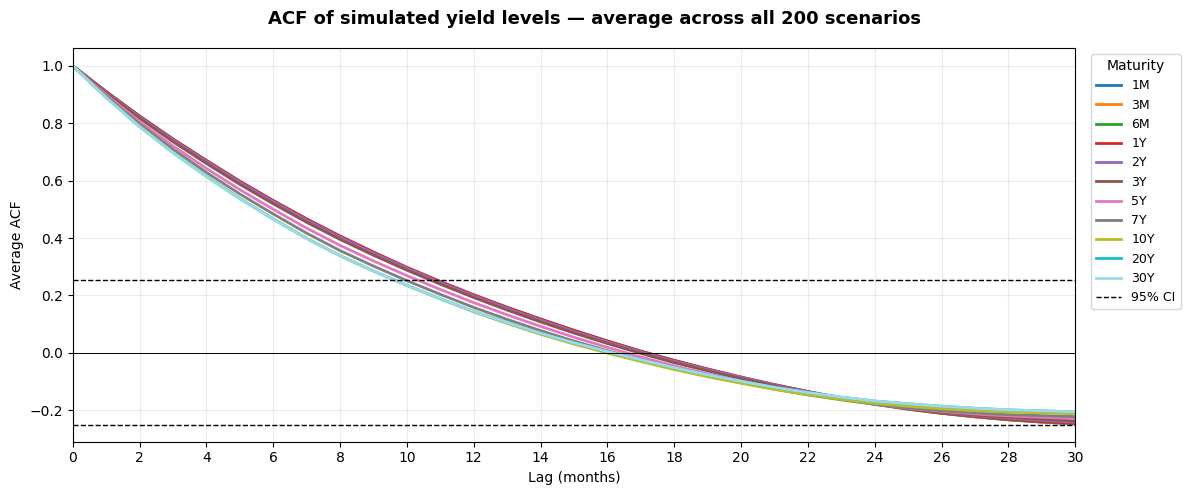

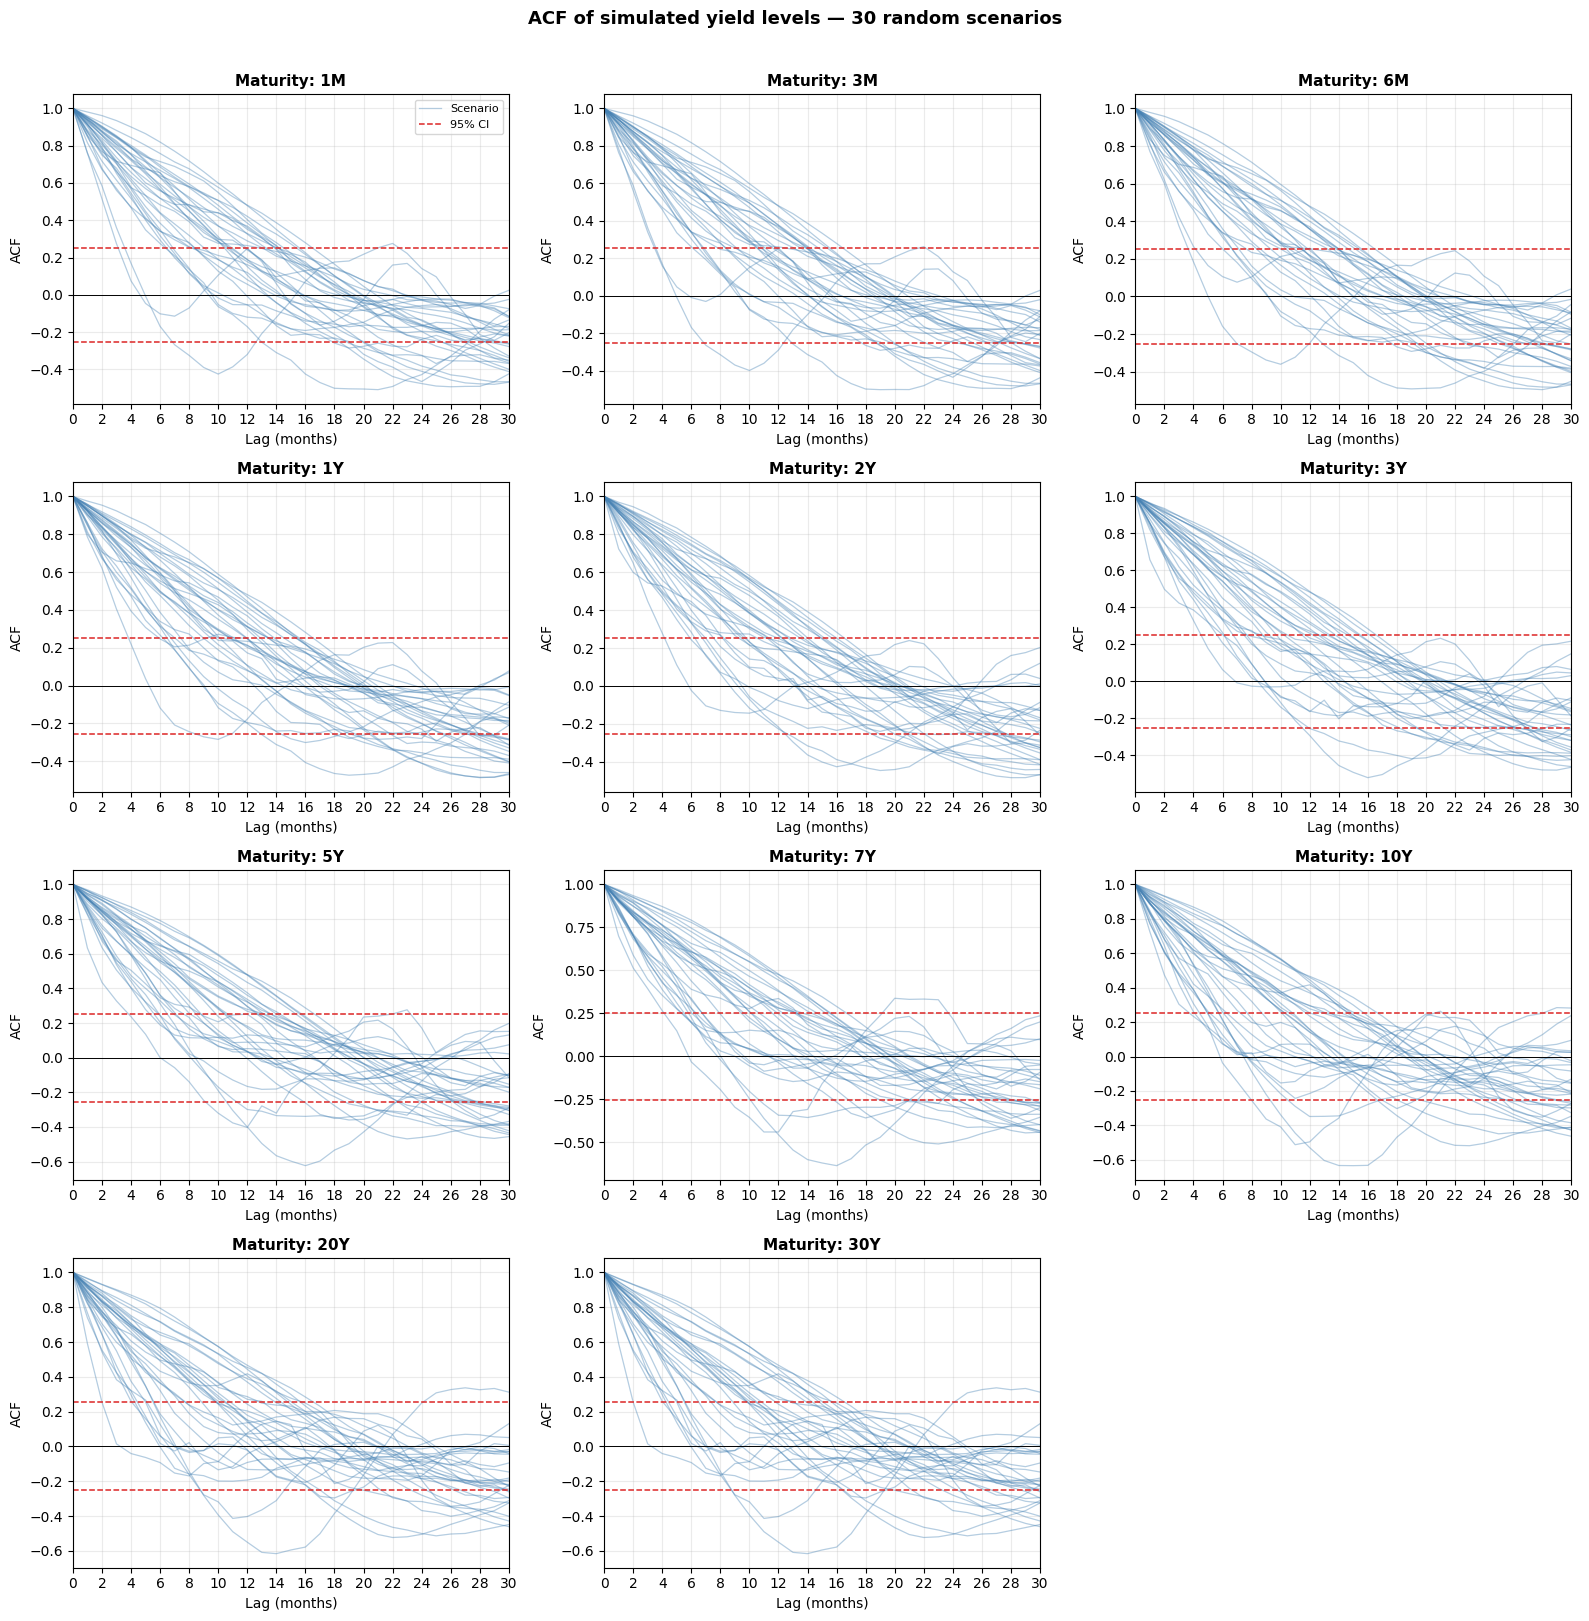

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

df = pd.read_csv(current_diffusion)

yield_cols  = [c for c in df.columns if c.startswith('Y_')]
maturities  = [c.replace('Y_', '') for c in yield_cols]
scenarios   = df['Scenario_ID'].unique()

N_LAGS    = 30
N_RANDOM  = 30
np.random.seed(42)

lags   = np.arange(N_LAGS + 1)
colors = plt.cm.tab20(np.linspace(0, 1, len(yield_cols)))
conf   = 1.96 / np.sqrt(60)   # 60 months per scenario

# Pick 30 random scenarios for the individual ACF plots
random_scenarios = np.random.choice(scenarios, size=N_RANDOM, replace=False)

# ── Figure 1: ACF per scenario (all 200), averaged → one line per maturity ───
fig1, ax1 = plt.subplots(figsize=(12, 5))
fig1.suptitle('ACF of simulated yield levels — average across all 200 scenarios',
              fontsize=13, fontweight='bold')

for (col, mat), color in zip(zip(yield_cols, maturities), colors):
    all_acfs = np.array([
        acf(df[df['Scenario_ID'] == s][col].values, nlags=N_LAGS, fft=True)
        for s in scenarios
    ])
    avg_acf = all_acfs.mean(axis=0)
    ax1.plot(lags, avg_acf, color=color, linewidth=2, label=mat)

ax1.axhline( conf, color='black', linewidth=1, linestyle='--', label='95% CI')
ax1.axhline(-conf, color='black', linewidth=1, linestyle='--')
ax1.axhline(0,     color='black', linewidth=0.7)
ax1.set_xlabel('Lag (months)')
ax1.set_ylabel('Average ACF')
ax1.set_xlim(0, N_LAGS)
ax1.set_xticks(range(0, N_LAGS + 1, 2))
ax1.legend(title='Maturity', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax1.grid(alpha=0.25)
plt.tight_layout()
#plt.savefig('acf_simulated_avg.png', dpi=150, bbox_inches='tight')

# ── Figure 2: 30 random scenarios per maturity (subplots) ────────────────────
n_cols = 3
n_rows = int(np.ceil(len(yield_cols) / n_cols))

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4), sharey=False)
fig2.suptitle('ACF of simulated yield levels — 30 random scenarios',
              fontsize=13, fontweight='bold', y=1.01)

for idx, (col, mat) in enumerate(zip(yield_cols, maturities)):
    ax = axes2.flatten()[idx]

    for i, s in enumerate(random_scenarios):
        series   = df[df['Scenario_ID'] == s][col].values
        acf_rand = acf(series, nlags=N_LAGS, fft=True)
        ax.plot(lags, acf_rand,
                color='steelblue', linewidth=0.9, alpha=0.4,
                label='Scenario' if i == 0 else None)

    ax.axhline( conf, color='#dc2626', linewidth=1.1, linestyle='--', label='95% CI')
    ax.axhline(-conf, color='#dc2626', linewidth=1.1, linestyle='--')
    ax.axhline(0,     color='black',   linewidth=0.7)
    ax.set_title(f'Maturity: {mat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('ACF')
    ax.set_xlim(0, N_LAGS)
    ax.set_xticks(range(0, N_LAGS + 1, 2))
    ax.grid(alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=8)

for idx in range(len(yield_cols), len(axes2.flatten())):
    axes2.flatten()[idx].set_visible(False)

plt.tight_layout()
#plt.savefig('acf_simulated_random_scenarios.png', dpi=150, bbox_inches='tight')

plt.show()

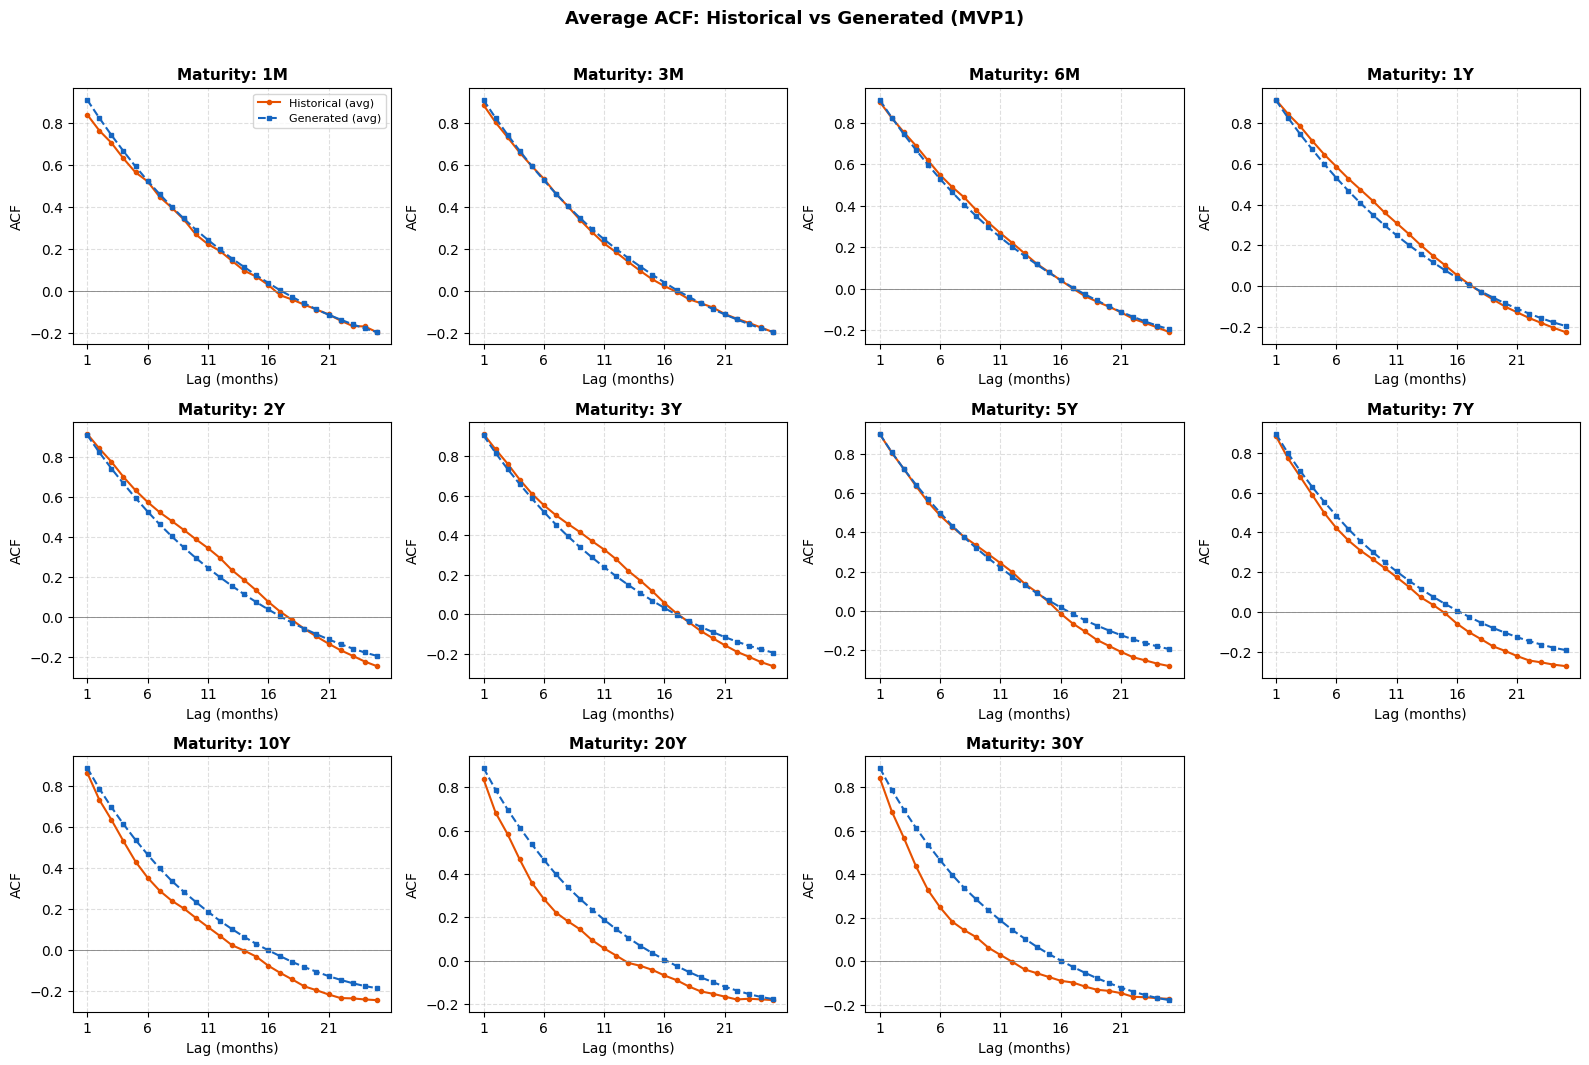

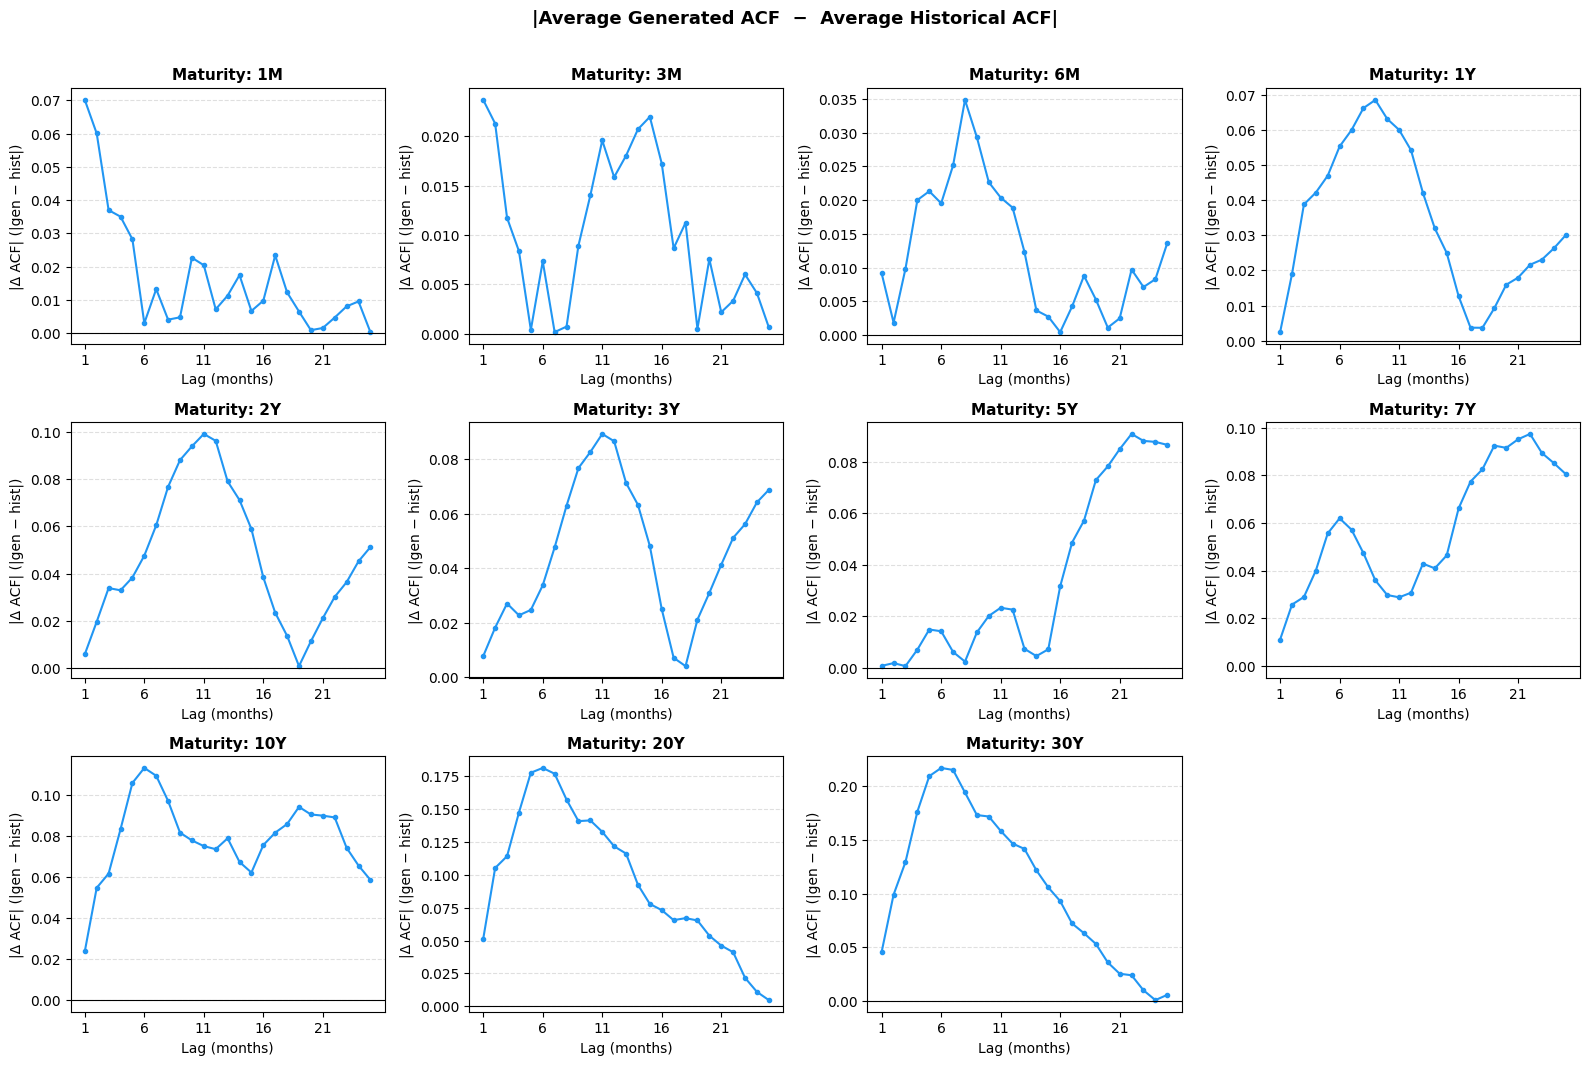

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import acf

# ── 0. Settings ────────────────────────────────────────────────────────────────
N_LAGS      = 25
WINDOW_SIZE = 60          # 5-year rolling window (months)

HIST_MATURITIES = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y','Yield_2Y',
                   'Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y','Yield_20Y','Yield_30Y']
GEN_MATURITIES  = ['Y_1M','Y_3M','Y_6M','Y_1Y','Y_2Y',
                   'Y_3Y','Y_5Y','Y_7Y','Y_10Y','Y_20Y','Y_30Y']
LABELS = ['1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']

# ── 1. Load & resample historical data to monthly ──────────────────────────────
hist = pd.read_csv(historical_data)
hist['DATE'] = pd.to_datetime(hist['DATE'])
hist = hist.set_index('DATE').sort_index()

# Last observation of each month
hist_monthly = hist[HIST_MATURITIES].resample('ME').last()

# ── 2. Rolling-window ACF on historical data ───────────────────────────────────
def rolling_avg_acf(series: pd.Series, window: int, n_lags: int) -> np.ndarray:
    """Return mean ACF across all rolling windows of length `window`."""
    acf_list = []
    values = series.dropna().values
    n = len(values)
    for start in range(n - window + 1):
        chunk = values[start:start + window]
        if np.std(chunk) < 1e-10:          # skip constant windows
            continue
        a = acf(chunk, nlags=n_lags, fft=True)[1:]   # drop lag-0 (=1)
        acf_list.append(a)
    return np.mean(acf_list, axis=0) if acf_list else np.full(n_lags, np.nan)

hist_avg_acf = {}          # label -> array(N_LAGS,)
for hcol, label in zip(HIST_MATURITIES, LABELS):
    hist_avg_acf[label] = rolling_avg_acf(hist_monthly[hcol], WINDOW_SIZE, N_LAGS)

# ── 3. Per-scenario ACF on generated data ─────────────────────────────────────
mvp = pd.read_csv(current_diffusion)
scenarios = mvp['Scenario_ID'].unique()

# gen_acfs[label] = array(n_scenarios, N_LAGS)
gen_acfs = {label: [] for label in LABELS}

for sid in scenarios:
    sc = mvp[mvp['Scenario_ID'] == sid].sort_values('Month')
    for gcol, label in zip(GEN_MATURITIES, LABELS):
        vals = sc[gcol].values
        if np.std(vals) < 1e-10:
            gen_acfs[label].append(np.zeros(N_LAGS))
        else:
            a = acf(vals, nlags=N_LAGS, fft=True)[1:]
            gen_acfs[label].append(a)

for label in LABELS:
    gen_acfs[label] = np.array(gen_acfs[label])   # (n_scenarios, N_LAGS)

# ── 4. Average generated ACF & ACFError ───────────────────────────────────────
# ACFError_i,m = (1/K) * sum_k |rho_gen_i,m(k) - rho_bar_hist_m(k)|
lags = np.arange(1, N_LAGS + 1)

results = {}
for label in LABELS:
    rho_hist  = hist_avg_acf[label]                   # (N_LAGS,)
    rho_gen   = gen_acfs[label]                        # (n_scenarios, N_LAGS)
    rho_gen_mean = rho_gen.mean(axis=0)               # (N_LAGS,)

    # ACFError per scenario
    acf_error = np.mean(np.abs(rho_gen - rho_hist[None, :]), axis=1)  # (n_scenarios,)

    results[label] = {
        'rho_hist':     rho_hist,
        'rho_gen_mean': rho_gen_mean,
        'acf_error':    acf_error,
        'diff':         rho_gen_mean - rho_hist,
    }

# ── 5. Plot: ACF curves overlay (hist vs gen) ──────────────────────────────────
n_mat = len(LABELS)
ncols = 4
nrows = int(np.ceil(n_mat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes_flat = axes.flatten()

for idx, label in enumerate(LABELS):
    ax = axes_flat[idx]
    rh = results[label]['rho_hist']
    rg = results[label]['rho_gen_mean']

    ax.plot(lags, rh, 'o-', color='#E65100', linewidth=1.5, markersize=3, label='Historical (avg)')
    ax.plot(lags, rg, 's--', color='#1565C0', linewidth=1.5, markersize=3, label='Generated (avg)')
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.set_title(f'Maturity: {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('ACF')
    ax.grid(linestyle='--', alpha=0.4)
    ax.set_xticks(lags[::5])
    if idx == 0:
        ax.legend(fontsize=8)

for ax in axes_flat[n_mat:]:
    ax.set_visible(False)

fig.suptitle('Average ACF: Historical vs Generated (MVP1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('acf_curves_per_maturity.png', dpi=150, bbox_inches='tight')

# ── 6. Plot: mean-generated ACF − historical ACF ──────────────────────────────
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes2_flat = axes2.flatten()

for idx, label in enumerate(LABELS):
    ax   = axes2_flat[idx]
    diff = results[label]['diff']

    ax.plot(lags, np.abs(diff), 'o-', color='#2196F3', linewidth=1.5, markersize=3)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Maturity: {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('|Δ ACF| (|gen − hist|)')
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_xticks(lags[::5])

for ax in axes2_flat[n_mat:]:
    ax.set_visible(False)

fig2.suptitle('|Average Generated ACF  −  Average Historical ACF|',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('acf_diff_per_maturity.png', dpi=150, bbox_inches='tight')

# ── 7. Save ACFError per scenario to CSV ──────────────────────────────────────
rows = []
for label in LABELS:
    for i, sid in enumerate(scenarios):
        rows.append({'Maturity': label, 'Scenario_ID': sid,
                     'ACFError': results[label]['acf_error'][i]})
#pd.DataFrame(rows).to_csv('acf_errors.csv', index=False)

In [36]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf

N_LAGS = 25
WINDOW_SIZE = 60

HIST_MATURITIES = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y','Yield_2Y',
                   'Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y','Yield_20Y','Yield_30Y']
GEN_MATURITIES  = ['Y_1M','Y_3M','Y_6M','Y_1Y','Y_2Y',
                   'Y_3Y','Y_5Y','Y_7Y','Y_10Y','Y_20Y','Y_30Y']
LABELS = ['1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']

hist = pd.read_csv(historical_data)
hist['DATE'] = pd.to_datetime(hist['DATE'])
hist = hist.set_index('DATE').sort_index()
hist_monthly = hist[HIST_MATURITIES].resample('ME').last()

def rolling_avg_acf(series, window, n_lags):
    acf_list = []
    values = series.dropna().values
    for start in range(len(values) - window + 1):
        chunk = values[start:start+window]
        if np.std(chunk) < 1e-10:
            continue
        acf_list.append(acf(chunk, nlags=n_lags, fft=True)[1:])
    return np.mean(acf_list, axis=0)

hist_avg_acf = {label: rolling_avg_acf(hist_monthly[hcol], WINDOW_SIZE, N_LAGS)
                for hcol, label in zip(HIST_MATURITIES, LABELS)}

mvp = pd.read_csv(current_diffusion)
scenarios = mvp['Scenario_ID'].unique()
gen_acfs = {label: [] for label in LABELS}
for sid in scenarios:
    sc = mvp[mvp['Scenario_ID']==sid].sort_values('Month')
    for gcol, label in zip(GEN_MATURITIES, LABELS):
        vals = sc[gcol].values
        a = acf(vals, nlags=N_LAGS, fft=True)[1:] if np.std(vals)>1e-10 else np.zeros(N_LAGS)
        gen_acfs[label].append(a)
for label in LABELS:
    gen_acfs[label] = np.array(gen_acfs[label])

# Mean ACFError per maturity
results = {}
for label in LABELS:
    e = np.mean(np.abs(gen_acfs[label] - hist_avg_acf[label][None,:]), axis=1)
    results[label] = e.mean()

df_result = pd.DataFrame.from_dict(results, orient='index', columns=['Mean ACFError'])
df_result.index.name = 'Maturity'

# Total average across all maturities
df_result.loc['TOTAL (avg)'] = df_result['Mean ACFError'].mean()

print(df_result.round(4).to_string())

             Mean ACFError
Maturity                  
1M                  0.1434
3M                  0.1398
6M                  0.1368
1Y                  0.1366
2Y                  0.1391
3Y                  0.1416
5Y                  0.1498
7Y                  0.1599
10Y                 0.1712
20Y                 0.1807
30Y                 0.1881
TOTAL (avg)         0.1534


## shape

Historical: 232 monthly observations
Historical betas shape: (232, 3)
Simulated betas shape: (30500, 3)
Plot saved.

=== Beta Summary ===

beta1 (Level)
  Historical: mean=3.8872  std=1.2133  min=1.1389  max=6.2272
  Simulated:  mean=5.0317  std=1.5556  min=-2.9344  max=11.9588

beta2 (Slope)
  Historical: mean=-2.5705  std=1.5472  min=-5.1687  max=0.7164
  Simulated:  mean=-1.2569  std=1.2046  min=-6.4262  max=3.9459

beta3 (Curvature)
  Historical: mean=-3.1544  std=2.1160  min=-7.3461  max=0.7381
  Simulated:  mean=-1.7851  std=1.7057  min=-7.5014  max=4.7420


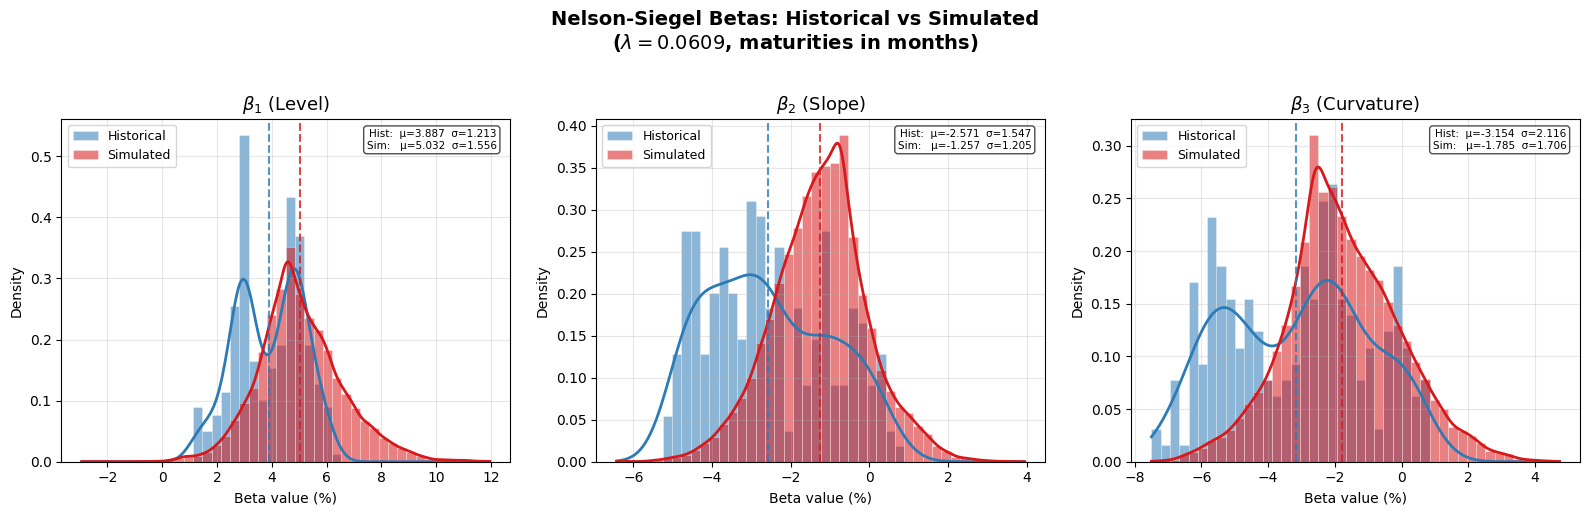

In [37]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609  # global lambda (monthly units)

# Maturities in years → convert to months
HIST_MATS_YR   = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO   = HIST_MATS_YR * 12

SIM_MATS_YR    = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
SIM_MATS_MO    = SIM_MATS_YR * 12

def ns_loadings(tau, lam):
    """Returns (N,3) matrix of NS factor loadings for maturities tau (months)."""
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    """Fit Nelson-Siegel betas by OLS (closed-form)."""
    X = ns_loadings(tau, lam)
    # OLS: beta = (X'X)^-1 X'y
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas  # [beta0, beta1, beta2]

# ── 1. Historical data → monthly ────────────────────────────────────────────
hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]

# Resample to month-end (last observation of each month)
hist_monthly = hist.resample('ME').last()
print(f"Historical: {len(hist_monthly)} monthly observations")

# Fit NS for each month
hist_betas = []
for idx, row in hist_monthly.iterrows():
    b = fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    hist_betas.append(b)
hist_betas = np.array(hist_betas)   # shape (T, 3)
print(f"Historical betas shape: {hist_betas.shape}")

# ── 2. Simulated data ────────────────────────────────────────────────────────
sim_yield_cols = ['Y_1M', 'Y_3M', 'Y_6M', 'Y_1Y', 'Y_2Y', 'Y_3Y', 'Y_5Y', 'Y_7Y',
                  'Y_10Y', 'Y_20Y', 'Y_30Y']

sim = pd.read_csv(current_diffusion)

sim_betas = []
for _, row in sim.iterrows():
    b = fit_ns_ols(row[sim_yield_cols].values, SIM_MATS_MO, LAMBDA)
    sim_betas.append(b)
sim_betas = np.array(sim_betas)   # shape (12000, 3)
print(f"Simulated betas shape: {sim_betas.shape}")

# ── 3. Plotting ──────────────────────────────────────────────────────────────
beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]
colors_hist = '#2c7bb6'
colors_sim  = '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nelson-Siegel Betas: Historical vs Simulated\n'
             r'($\lambda = 0.0609$, maturities in months)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, beta_labels)):
    h_vals = hist_betas[:, i]
    s_vals = sim_betas[:, i]

    # Determine common bin range
    lo = min(h_vals.min(), s_vals.min())
    hi = max(h_vals.max(), s_vals.max())
    bins = np.linspace(lo, hi, 45)

    ax.hist(h_vals, bins=bins, density=True, alpha=0.55,
            color=colors_hist, label='Historical', edgecolor='white', linewidth=0.4)
    ax.hist(s_vals, bins=bins, density=True, alpha=0.55,
            color=colors_sim,  label='Simulated',  edgecolor='white', linewidth=0.4)

    # Add KDE lines
    from scipy.stats import gaussian_kde
    x_grid = np.linspace(lo, hi, 300)
    for vals, color in [(h_vals, colors_hist), (s_vals, colors_sim)]:
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    # Summary stats
    ax.axvline(h_vals.mean(), color=colors_hist, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(s_vals.mean(), color=colors_sim,  linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Beta value (%)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Text box with stats
    stats_txt = (f"Hist:  μ={h_vals.mean():.3f}  σ={h_vals.std():.3f}\n"
                 f"Sim:   μ={s_vals.mean():.3f}  σ={s_vals.std():.3f}")
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
#plt.savefig('ns_beta_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 4. Print summary table ───────────────────────────────────────────────────
print("\n=== Beta Summary ===")
for i, name in enumerate(['beta1 (Level)', 'beta2 (Slope)', 'beta3 (Curvature)']):
    h, s = hist_betas[:, i], sim_betas[:, i]
    print(f"\n{name}")
    print(f"  Historical: mean={h.mean():.4f}  std={h.std():.4f}  "
          f"min={h.min():.4f}  max={h.max():.4f}")
    print(f"  Simulated:  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}")

In [38]:
from scipy.stats import wasserstein_distance
import pandas as pd
import numpy as np

# =========================
# FUNCTION
# =========================
def compute_wasserstein(hist_betas, sim_betas):
    results = []

    names = ["Level (β1)", "Slope (β2)", "Curvature (β3)"]

    for i, name in enumerate(names):
        h = hist_betas[:, i]
        s = sim_betas[:, i]

        w = wasserstein_distance(h, s)

        results.append({
            "Beta": name,
            "Wasserstein Distance": w,
            "Hist Mean": np.mean(h),
            "Sim Mean": np.mean(s),
            "Hist Std": np.std(h),
            "Sim Std": np.std(s)
        })

    return pd.DataFrame(results)

# =========================
# RUN
# =========================
comparison = compute_wasserstein(hist_betas, sim_betas)

print("\n=== Wasserstein Comparison ===")
print(comparison)


=== Wasserstein Comparison ===
             Beta  Wasserstein Distance  Hist Mean  Sim Mean  Hist Std  \
0      Level (β1)              1.152704   3.887218  5.031655  1.213318   
1      Slope (β2)              1.314491  -2.570515 -1.256921  1.547219   
2  Curvature (β3)              1.369323  -3.154369 -1.785072  2.116042   

    Sim Std  
0  1.555614  
1  1.204648  
2  1.705706  


shape maar met pca (we gebruiken NS, dit puur voor onszelf)

Historical monthly obs: 232
  PC1: 84.14%
  PC2: 14.77%
  PC3: 0.86%
  Total: 99.78%
Hist scores: (232, 3), Sim scores: (30500, 3)
Plot saved.

=== PCA Loadings ===
Maturity           PC1       PC2       PC3
Yield_1M        0.2973   -0.3161   -0.3986
Yield_3M        0.2997   -0.3119   -0.3127
Yield_6M        0.3027   -0.3005   -0.1948
Yield_1Y        0.3087   -0.2667   -0.0127
Yield_2Y        0.3190   -0.1718    0.2807
Yield_3Y        0.3241   -0.0798    0.4126
Yield_5Y        0.3236    0.0960    0.3951
Yield_7Y        0.3138    0.2199    0.2771
Yield_10Y       0.2988    0.3250    0.0227
Yield_20Y       0.2672    0.4503   -0.2655
Yield_30Y       0.2532    0.4894   -0.3902


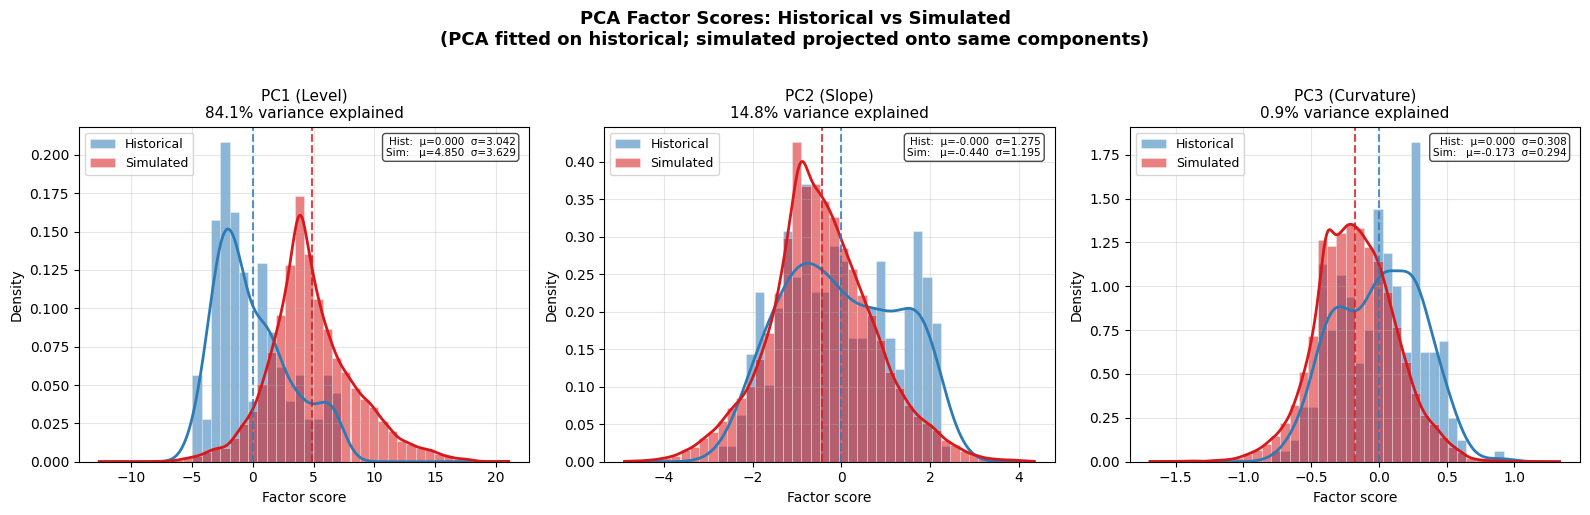

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# ── 1. Historical monthly data ───────────────────────────────────────────────
hist_cols = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y','Yield_2Y',
             'Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y','Yield_20Y','Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols].resample('ME').last()
print(f"Historical monthly obs: {len(hist)}")

# ── 2. Fit PCA on historical ─────────────────────────────────────────────────
scaler = StandardScaler()
hist_scaled = scaler.fit_transform(hist.values)

pca = PCA(n_components=3)
pca.fit(hist_scaled)

for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ── 3. Project both datasets onto same PCA components ────────────────────────
hist_scores = pca.transform(hist_scaled)

sim_yield_cols = ['Y_1M','Y_3M','Y_6M','Y_1Y','Y_2Y','Y_3Y','Y_5Y','Y_7Y','Y_10Y','Y_20Y','Y_30Y']
sim = pd.read_csv(current_diffusion)
sim_scaled = scaler.transform(sim[sim_yield_cols].values)  # same scaler!
sim_scores = pca.transform(sim_scaled)                     # same components!
print(f"Hist scores: {hist_scores.shape}, Sim scores: {sim_scores.shape}")

# ── 4. Plot distributions ─────────────────────────────────────────────────────
labels = [
    f'PC1 (Level)\n{pca.explained_variance_ratio_[0]*100:.1f}% variance explained',
    f'PC2 (Slope)\n{pca.explained_variance_ratio_[1]*100:.1f}% variance explained',
    f'PC3 (Curvature)\n{pca.explained_variance_ratio_[2]*100:.1f}% variance explained',
]
C_HIST, C_SIM = '#2c7bb6', '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PCA Factor Scores: Historical vs Simulated\n'
             '(PCA fitted on historical; simulated projected onto same components)',
             fontsize=13, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, labels)):
    h, s = hist_scores[:, i], sim_scores[:, i]
    lo = min(h.min(), s.min())
    hi = max(h.max(), s.max())
    bins = np.linspace(lo, hi, 45)
    x_grid = np.linspace(lo, hi, 300)

    ax.hist(h, bins=bins, density=True, alpha=0.55, color=C_HIST,
            label='Historical', edgecolor='white', lw=0.4)
    ax.hist(s, bins=bins, density=True, alpha=0.55, color=C_SIM,
            label='Simulated',  edgecolor='white', lw=0.4)
    for vals, c in [(h, C_HIST), (s, C_SIM)]:
        ax.plot(x_grid, gaussian_kde(vals, bw_method='scott')(x_grid), color=c, lw=2)
    ax.axvline(h.mean(), color=C_HIST, ls='--', lw=1.5, alpha=0.8)
    ax.axvline(s.mean(), color=C_SIM,  ls='--', lw=1.5, alpha=0.8)

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Factor score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.97,
            f"Hist:  μ={h.mean():.3f}  σ={h.std():.3f}\nSim:   μ={s.mean():.3f}  σ={s.std():.3f}",
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
# plt.savefig('pca_factor_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 5. Loadings table ────────────────────────────────────────────────────────
print("\n=== PCA Loadings ===")
header = f"{'Maturity':<12}" + "".join([f"{'PC'+str(i+1):>10}" for i in range(3)])
print(header)
for mat, row in zip(hist_cols, pca.components_.T):
    line = f"{mat:<12}" + "".join([f"{v:>10.4f}" for v in row])
    print(line)

## cross-maturity correlatie

Loading historical data …
  Monthly observations: 232  (2002-01 → 2021-04)

Computing historical cross-correlation matrices (window = 60 months, stride = 1) …
  Number of 5-year windows: 173
  Mean cross-correlation matrix shape: (11, 11)

Loading simulated paths …
  Scenarios: 500  |  Months per scenario: [61]
Computing simulated cross-correlation matrices …
  Mean cross-correlation matrix shape: (11, 11)

──────────────────────────────────────────────────
  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  16.353217
  (d=11 maturities  →  121 matrix entries)
──────────────────────────────────────────────────


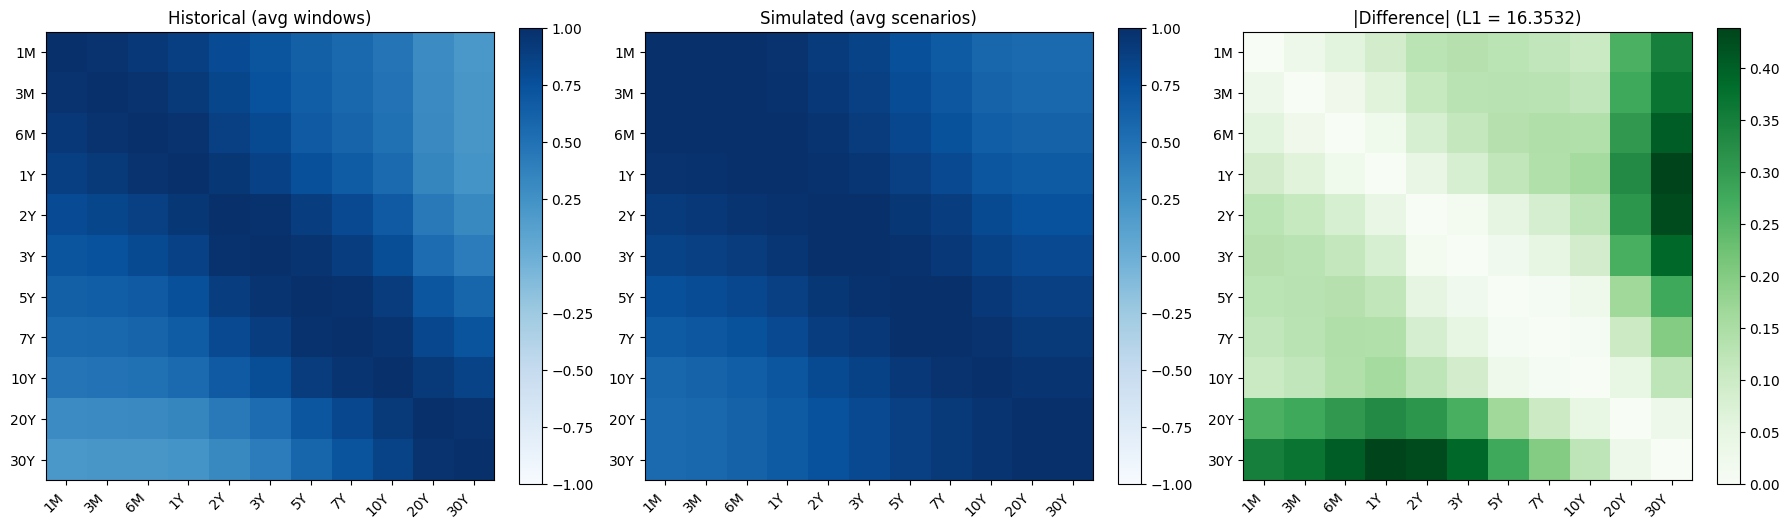


── Historical mean cross-correlation matrix ──
         1M      3M      6M      1Y      2Y      3Y      5Y      7Y     10Y     20Y     30Y
1M   1.0000  0.9695  0.9344  0.8822  0.7859  0.7165  0.6253  0.5548  0.4750  0.2906  0.2027
3M   0.9695  1.0000  0.9716  0.9192  0.8209  0.7457  0.6461  0.5707  0.4884  0.3004  0.2089
6M   0.9344  0.9716  1.0000  0.9694  0.8732  0.7902  0.6794  0.5963  0.5033  0.3059  0.2072
1Y   0.8822  0.9192  0.9694  1.0000  0.9422  0.8666  0.7511  0.6595  0.5493  0.3364  0.2275
2Y   0.7859  0.8209  0.8732  0.9422  1.0000  0.9770  0.8903  0.8000  0.6723  0.4365  0.3178
3Y   0.7165  0.7457  0.7902  0.8666  0.9770  1.0000  0.9585  0.8873  0.7668  0.5327  0.4107
5Y   0.6253  0.6461  0.6794  0.7511  0.8903  0.9585  1.0000  0.9788  0.9036  0.7066  0.5923
7Y   0.5548  0.5707  0.5963  0.6595  0.8000  0.8873  0.9788  1.0000  0.9679  0.8186  0.7196
10Y  0.4750  0.4884  0.5033  0.5493  0.6723  0.7668  0.9036  0.9679  1.0000  0.9229  0.8452
20Y  0.2906  0.3004  0.3059  0.3

In [40]:
"""
Cross-Maturity Correlation Analysis
Based on Liao et al. (2024) "Sig-Wasserstein GANs for conditional time series generation"
Cross-correlation metric: Appendix C, Equations (C.3) and (C.4)

L1 norm of real vs generated cross-correlation matrices:
    metric = sum_i sum_j |tau^{i,j}_r - tau^{i,j}_G|

where tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# 0. Configuration
# ─────────────────────────────────────────────
YIELD_COLS_HIST = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y",
    "Yield_2Y", "Yield_3Y", "Yield_5Y", "Yield_7Y",
    "Yield_10Y", "Yield_20Y", "Yield_30Y"
]
YIELD_COLS_SIM = [
    "Y_1M", "Y_3M", "Y_6M", "Y_1Y",
    "Y_2Y", "Y_3Y", "Y_5Y", "Y_7Y",
    "Y_10Y", "Y_20Y", "Y_30Y"
]
MATURITY_LABELS = [
    "1M", "3M", "6M", "1Y",
    "2Y", "3Y", "5Y", "7Y",
    "10Y", "20Y", "30Y"
]
WINDOW_MONTHS = 60   # 5-year sliding window to match 60-month simulated paths

# ─────────────────────────────────────────────
# 1. Helper: cross-correlation matrix per Eq (C.3)
# ─────────────────────────────────────────────
def cross_corr_matrix(X: np.ndarray) -> np.ndarray:
    """
    X : (T, d) array of time series observations
    Returns (d, d) correlation matrix tau where
        tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
    using the unbiased sample estimator from paper Eq (C.3):
        cov^{i,j} = (1/T) sum_t X^i_t X^j_t - (1/T sum X^i)(1/T sum X^j)
    """
    T = X.shape[0]
    mean = X.mean(axis=0)                    # (d,)
    cov = (X.T @ X) / T - np.outer(mean, mean)   # (d, d)  -- Eq (C.3)
    std = np.sqrt(np.diag(cov))              # (d,)
    outer_std = np.outer(std, std)
    # avoid div/0
    corr = np.where(outer_std > 0, cov / outer_std, 0.0)
    return corr

# ─────────────────────────────────────────────
# 2. Load & pre-process historical data
# ─────────────────────────────────────────────
print("Loading historical data …")
hist = pd.read_csv(historical_data)

# Remove GDP, Fed Funds and CPI columns; keep only yield curve
# GDP → Real_GDP | Fed → FedFunds | (CPI_Level implicitly removed)
hist = hist[["DATE"] + YIELD_COLS_HIST].copy()
hist["DATE"] = pd.to_datetime(hist["DATE"])
hist = hist.sort_values("DATE").reset_index(drop=True)

# Aggregate daily → monthly (end-of-month last observation)
hist["YearMonth"] = hist["DATE"].dt.to_period("M")
hist_monthly = (hist.groupby("YearMonth")[YIELD_COLS_HIST]
                .last()
                .reset_index())
hist_monthly = hist_monthly.sort_values("YearMonth").reset_index(drop=True)

n_months = len(hist_monthly)
print(f"  Monthly observations: {n_months}  "
      f"({hist_monthly['YearMonth'].iloc[0]} → {hist_monthly['YearMonth'].iloc[-1]})")

# ─────────────────────────────────────────────
# 3. Sliding-window cross-correlation matrices (historical)
# ─────────────────────────────────────────────
print(f"\nComputing historical cross-correlation matrices "
      f"(window = {WINDOW_MONTHS} months, stride = 1) …")

hist_values = hist_monthly[YIELD_COLS_HIST].values  # (n_months, 11)
n_windows = n_months - WINDOW_MONTHS + 1

hist_corr_matrices = []
for start in range(n_windows):
    window = hist_values[start : start + WINDOW_MONTHS]   # (60, 11)
    hist_corr_matrices.append(cross_corr_matrix(window))

hist_corr_matrices = np.array(hist_corr_matrices)   # (n_windows, 11, 11)
hist_mean_corr = hist_corr_matrices.mean(axis=0)    # average across windows

print(f"  Number of 5-year windows: {n_windows}")
print(f"  Mean cross-correlation matrix shape: {hist_mean_corr.shape}")

# ─────────────────────────────────────────────
# 4. Load & process simulated data
# ─────────────────────────────────────────────
print("\nLoading simulated paths …")
sim = pd.read_csv(current_diffusion)
scenarios = sim["Scenario_ID"].unique()
n_scenarios = len(scenarios)
months_per_scenario = sim.groupby("Scenario_ID")["Month"].count().unique()
print(f"  Scenarios: {n_scenarios}  |  Months per scenario: {months_per_scenario}")

# Per paper Eq (C.4): compute cov matrix per scenario, then average
print("Computing simulated cross-correlation matrices …")
sim_corr_matrices = []
for sc_id in scenarios:
    sc_data = sim[sim["Scenario_ID"] == sc_id][YIELD_COLS_SIM].values  # (60, 11)
    sim_corr_matrices.append(cross_corr_matrix(sc_data))

sim_corr_matrices = np.array(sim_corr_matrices)     # (n_scenarios, 11, 11)
sim_mean_corr = sim_corr_matrices.mean(axis=0)       # average across scenarios

print(f"  Mean cross-correlation matrix shape: {sim_mean_corr.shape}")

# ─────────────────────────────────────────────
# 5. L1 norm  (paper Section 6, Feature dependency metric)
# ─────────────────────────────────────────────
diff_matrix = np.abs(hist_mean_corr - sim_mean_corr)
l1_norm = diff_matrix.sum()

print(f"\n{'─'*50}")
print(f"  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  {l1_norm:.6f}")
print(f"  (d={len(MATURITY_LABELS)} maturities  →  {len(MATURITY_LABELS)**2} matrix entries)")
print(f"{'─'*50}")

# ─────────────────────────────────────────────
# 6. Visualisation (clean white style)
# ─────────────────────────────────────────────
plt.style.use("default")  # reset to standard white theme

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Historical
im0 = axes[0].imshow(hist_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[0].set_title("Historical (avg windows)")

# Simulated
im1 = axes[1].imshow(sim_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[1].set_title("Simulated (avg scenarios)")

# Difference
im2 = axes[2].imshow(diff_matrix, cmap="Greens")
axes[2].set_title(f"|Difference| (L1 = {l1_norm:.4f})")

# Axis labels
for ax in axes:
    ax.set_xticks(range(len(MATURITY_LABELS)))
    ax.set_yticks(range(len(MATURITY_LABELS)))
    ax.set_xticklabels(MATURITY_LABELS, rotation=45, ha="right")
    ax.set_yticklabels(MATURITY_LABELS)

# Colorbars
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. Print summary table
# ─────────────────────────────────────────────
print("\n── Historical mean cross-correlation matrix ──")
df_hist = pd.DataFrame(hist_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_hist.round(4).to_string())

print("\n── Simulated mean cross-correlation matrix ──")
df_sim = pd.DataFrame(sim_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_sim.round(4).to_string())

print("\n── |Difference| matrix ──")
df_diff = pd.DataFrame(diff_matrix, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_diff.round(4).to_string())

print(f"\n{'═'*50}")
print(f"  FINAL  L¹ norm = {l1_norm:.6f}")
print(f"{'═'*50}")
print("\nDone.")
